In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [171]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [173]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [174]:
df.duplicated().sum()

np.int64(1)

In [175]:
df = df.drop_duplicates()

In [176]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## EDA

#### Heart Disease Distribution

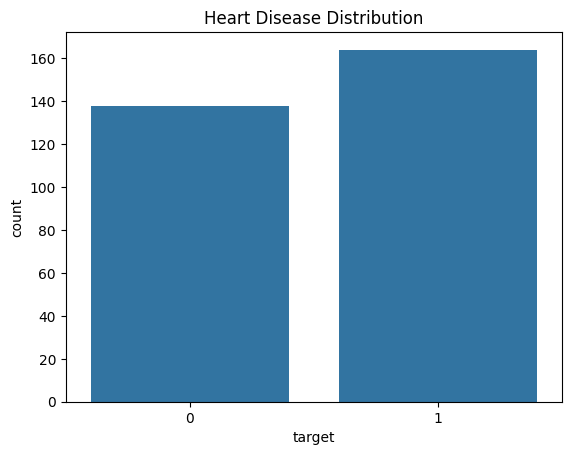

In [177]:
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

#### Age Distribution vs Heart Disease

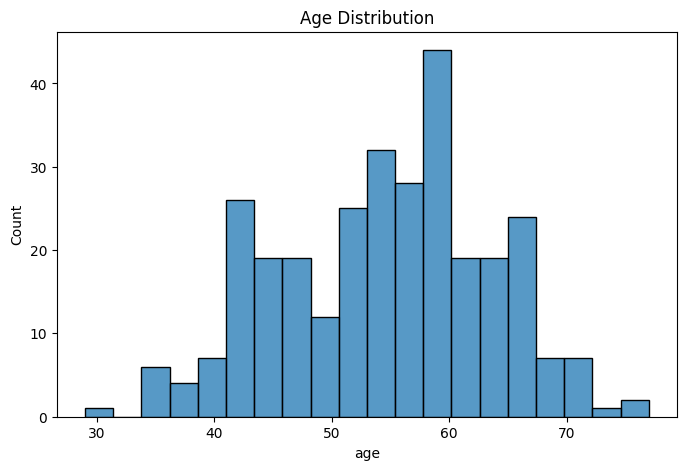

In [178]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()           ## Older people have higher risk of heart disease.

#### Correlation Heatmap

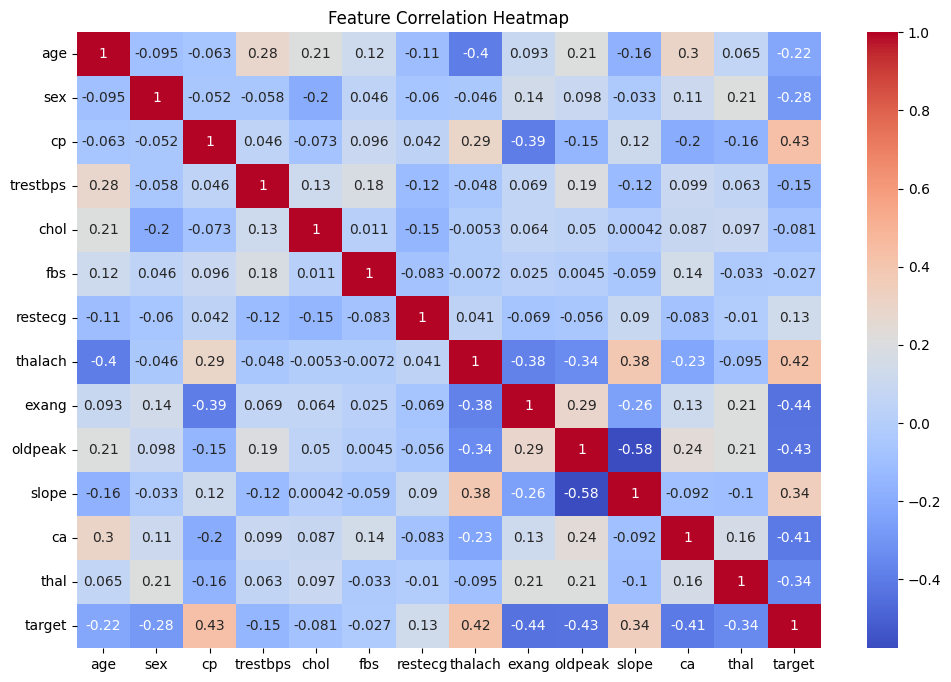

In [179]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Cholesterol vs Heart Disease

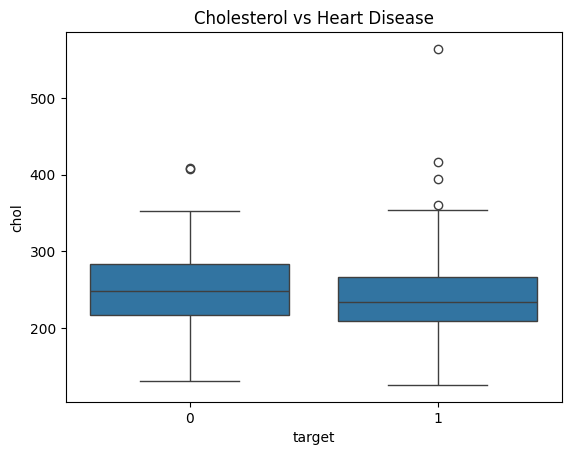

In [180]:
sns.boxplot(x="target", y="chol", data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()            ## Higher cholesterol patients show more heart disease cases.

## Feature & Target Split

In [181]:
X = df.drop("target", axis=1)
y = df["target"]

## Train Test Split

In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## StandardScaler (Preprocessing)

In [183]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

In [184]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [185]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [186]:
y_pred_lr = lr.predict(X_test_scaled) 
y_pred_lr

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [187]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Logistic Regression Metrics")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

print("--------------------------------")

Logistic Regression Metrics
Accuracy: 0.8688524590163934
Precision: 0.8611111111111112
Recall: 0.9117647058823529
F1 Score: 0.8857142857142857
ROC-AUC: 0.8632897603485838
--------------------------------


## Random Forest Model

##### Random Forest ko scaling ki zarurat nahi hoti.

In [188]:
from sklearn.ensemble import RandomForestClassifier

In [189]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [190]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [191]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8688524590163934


In [192]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Random Forest Metrics")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

print("--------------------------------")

Random Forest Metrics
Accuracy: 0.8688524590163934
Precision: 0.90625
Recall: 0.8529411764705882
F1 Score: 0.8787878787878788
ROC-AUC: 0.8709150326797386
--------------------------------


## Decision Tree Model

In [193]:
from sklearn.tree import DecisionTreeClassifier

In [194]:
DT = DecisionTreeClassifier()

DT.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [195]:
y_pred_dt = DT.predict(X_test)
y_pred_dt

array([0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [196]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Decision Tree Metrics")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_dt))

print("--------------------------------")

Decision Tree Metrics
Accuracy: 0.7704918032786885
Precision: 0.8125
Recall: 0.7647058823529411
F1 Score: 0.7878787878787878
ROC-AUC: 0.7712418300653595
--------------------------------


## Feature Importance

In [197]:
if accuracy_score(y_test, y_pred_rf) > accuracy_score(y_test, y_pred_lr):
    print("Random Forest is best model")
else:
    print("Logistic Regression is best model")

Logistic Regression is best model


In [198]:
importance = rf.feature_importances_
importance

array([0.08950381, 0.04395067, 0.11503086, 0.07121647, 0.0768321 ,
       0.01002805, 0.01920859, 0.11699821, 0.05086688, 0.11709081,
       0.05188493, 0.1364438 , 0.10094482])

In [199]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

print(feature_importance)

     Feature  Importance
11        ca    0.136444
9    oldpeak    0.117091
7    thalach    0.116998
2         cp    0.115031
12      thal    0.100945
0        age    0.089504
4       chol    0.076832
3   trestbps    0.071216
10     slope    0.051885
8      exang    0.050867
1        sex    0.043951
6    restecg    0.019209
5        fbs    0.010028


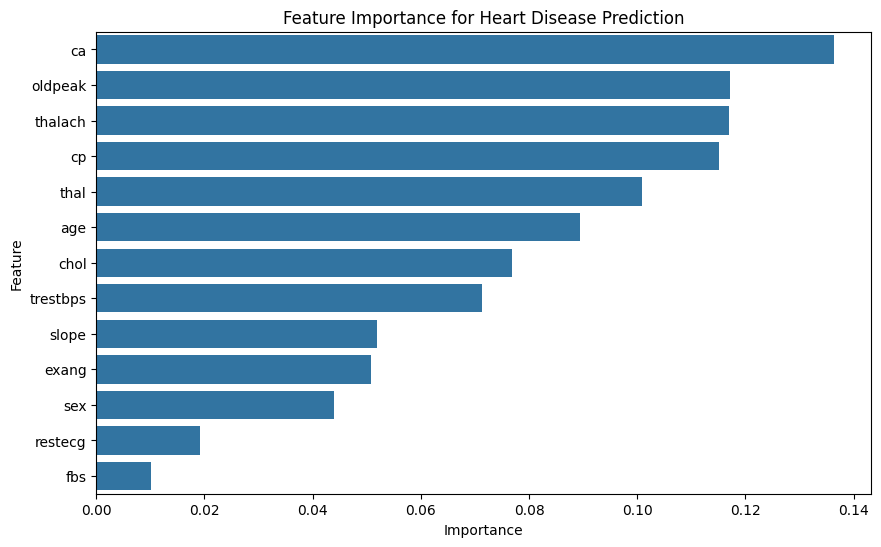

In [200]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance for Heart Disease Prediction")
plt.show()

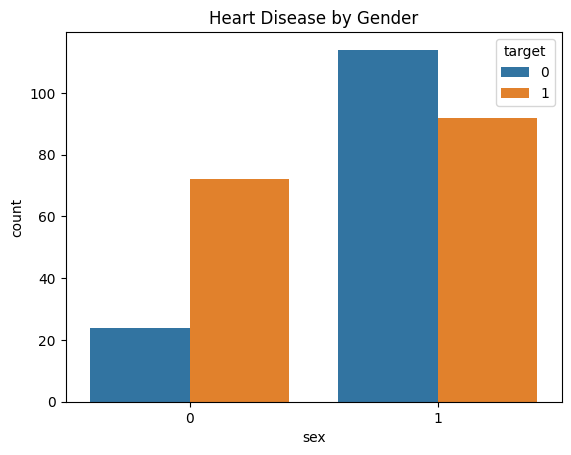

In [201]:
sns.countplot(x="sex", hue="target", data=df)
plt.title("Heart Disease by Gender")
plt.show()

## Confusion Matrix
#### Isse pata chalta hai model kaha galti kar raha hai.

In [215]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)      ## Sab sahi hain .. kuchh glti nhi h..

[[24  3]
 [ 5 29]]


In [209]:
sample = df.sample(1)

print(sample)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
262   53    1   0       123   282    0        1       95      1      2.0   

     slope  ca  thal  target  
262      1   2     3       0  


In [210]:
values = sample.drop("target",axis=1).values[0]

print("Actual:", sample["target"].values[0])

print("Prediction:", predict_heart_disease(values))

Actual: 0
Prediction: ✅ No Heart Disease


# Model Testing with Sample Inputs
#### Heart Disease Prediction System

In [213]:
import pandas as pd

# sample test values
tests = [
    [37,1,2,130,250,0,1,187,0,0.0,2,0,2],
    [63,1,3,145,233,1,0,150,1,2.3,0,2,1],
    [41,0,1,130,204,0,0,172,0,1.4,2,0,2],
    [56,1,2,120,236,0,1,178,0,0.8,2,0,2],
    [57,1,0,140,192,0,1,148,0,0.4,1,0,1]
]

for t in tests:

    # convert to dataframe
    data = pd.DataFrame([t], columns=X.columns)

    # prediction
    pred = rf.predict(data)[0]

    # probability
    prob = rf.predict_proba(data)[0][1]

    if pred == 1:
        print(t, "→ ⚠ Heart Disease Detected")
    else:
        print(t, "→ ✅ No Heart Disease")

    print("Risk Probability:", round(prob,2))
    print("--------------------------------")

[37, 1, 2, 130, 250, 0, 1, 187, 0, 0.0, 2, 0, 2] → ⚠ Heart Disease Detected
Risk Probability: 0.98
--------------------------------
[63, 1, 3, 145, 233, 1, 0, 150, 1, 2.3, 0, 2, 1] → ✅ No Heart Disease
Risk Probability: 0.4
--------------------------------
[41, 0, 1, 130, 204, 0, 0, 172, 0, 1.4, 2, 0, 2] → ⚠ Heart Disease Detected
Risk Probability: 0.99
--------------------------------
[56, 1, 2, 120, 236, 0, 1, 178, 0, 0.8, 2, 0, 2] → ⚠ Heart Disease Detected
Risk Probability: 0.97
--------------------------------
[57, 1, 0, 140, 192, 0, 1, 148, 0, 0.4, 1, 0, 1] → ⚠ Heart Disease Detected
Risk Probability: 0.74
--------------------------------


# Heart Disease Prediction System

This section allows the user to enter patient details and predict whether the patient has heart disease or not using the trained Random Forest model.

In [216]:
import pandas as pd

def heart_predictor():

    print("Enter Patient Details\n")

    age = float(input("Age: "))
    sex = float(input("Sex (1 = Male, 0 = Female): "))
    cp = float(input("Chest Pain Type (0-3): "))
    trestbps = float(input("Resting Blood Pressure: "))
    chol = float(input("Cholesterol: "))
    fbs = float(input("Fasting Blood Sugar (>120 = 1, else 0): "))
    restecg = float(input("Rest ECG (0-2): "))
    thalach = float(input("Max Heart Rate: "))
    exang = float(input("Exercise Angina (1 = Yes, 0 = No): "))
    oldpeak = float(input("Oldpeak: "))
    slope = float(input("Slope (0-2): "))
    ca = float(input("Number of Major Vessels (0-3): "))
    thal = float(input("Thal (1 = normal, 2 = fixed defect, 3 = reversible defect): "))

    values = [age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal]

    data = pd.DataFrame([values], columns=X.columns)

    prediction = rf.predict(data)[0]

    probability = rf.predict_proba(data)[0][1]

    print("\n----- Prediction Result -----")

    if prediction == 1:
        print("⚠ Heart Disease Detected")
    else:
        print("✅ No Heart Disease")

    print("Disease Probability:", round(probability,2))

In [218]:
heart_predictor()

Enter Patient Details



Age:  63
Sex (1 = Male, 0 = Female):  1
Chest Pain Type (0-3):  3
Resting Blood Pressure:  145
Cholesterol:  233
Fasting Blood Sugar (>120 = 1, else 0):  1
Rest ECG (0-2):  0
Max Heart Rate:  150
Exercise Angina (1 = Yes, 0 = No):  1
Oldpeak:  2.3
Slope (0-2):  0
Number of Major Vessels (0-3):  2
Thal (1 = normal, 2 = fixed defect, 3 = reversible defect):  1



----- Prediction Result -----
✅ No Heart Disease
Disease Probability: 0.4


In [219]:
import pickle

pickle.dump(rf, open("heart_model.pkl", "wb"))